# Embedding for Sentiment Analysis 

Now that we know how word embedding works, we'll apply it to a supervised problem of sentiment analysis. The idea is to classify the comments left by users according to the number of stars they gave the Disneyland resort park in their reviews.

## Data Preprocessing

### Import Data 

1. Import the necessary libraries

In [2]:
import io
import os
import re
import shutil
import tarfile
import string
import torch
import tiktoken
import requests
import numpy as np
import pandas as pd
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using mps device


2. Copy the link below and read the file it contains with `pandas`.

* https://go.aws/314bBDq

In [3]:
# Import dataset with Pandas 
import pandas as pd

url = "https://go.aws/314bBDq"
df = pd.read_csv(url)
print("Columns:", list(df.columns))
print("Shape:", df.shape)
df.head()


Columns: ['user_id', 'review', 'stars', 'date_format', 'time_of_day', 'hour_of_day', 'day_of_week', 'review_format', 'review_lang', 'month_year', 'review_len', 'review_nb_words']
Shape: (299635, 12)


,user_id,review,stars,date_format,time_of_day,hour_of_day,day_of_week,review_format,review_lang,month_year,review_len,review_nb_words
0,efb62a167fee5cf3678b24427de8e31f,"Génial, fabuleux, exceptionnel ! J'aimerais qu...",5,2017-09-29 18:17:00,18:17,18,Ven,génial fabuleux exceptionnel j aimerais qu...,french,2017-09,115,19
1,e3be4f9c9e0b9572bfb2a5f88497bb14,NaN,2,2017-09-29 17:29:00,17:29,17,Ven,NaN,NaN,2017-09,0,0
2,1b8e5760162d867e9b9ca80f645bdc60,"Toujours aussi magic, féerique !",5,2017-09-29 16:46:00,16:46,16,Ven,toujours aussi magic féerique,french,2017-09,32,4
3,fa330e5891a1bb486c3e9bf95c098726,NaN,5,2017-09-29 15:52:00,15:52,15,Ven,NaN,NaN,2017-09,0,0
4,c1a693206aee1a2412d4bd9e45b80ec5,NaN,3,2017-09-29 15:29:00,15:29,15,Ven,NaN,NaN,2017-09,0,0


3. We will need the reviews in French. Filter the reviews so that they are in the right language. For this you need to find a column that gives you that information.

In [4]:
# Taking only french reviews
# Try common language column names and filter to French ('fr' or 'FR')
lang_col = None
for c in ["language", "lang", "Language", "locale", "Locale"]:
    if c in df.columns:
        lang_col = c
        break

if lang_col is not None:
    df = df[df[lang_col].astype(str).str.lower().str.startswith("fr")].copy()
else:
    print("⚠️ Could not find a language column; keeping all rows.")

print(df.shape)
df.head()


⚠️ Could not find a language column; keeping all rows.
(299635, 12)


,user_id,review,stars,date_format,time_of_day,hour_of_day,day_of_week,review_format,review_lang,month_year,review_len,review_nb_words
0,efb62a167fee5cf3678b24427de8e31f,"Génial, fabuleux, exceptionnel ! J'aimerais qu...",5,2017-09-29 18:17:00,18:17,18,Ven,génial fabuleux exceptionnel j aimerais qu...,french,2017-09,115,19
1,e3be4f9c9e0b9572bfb2a5f88497bb14,NaN,2,2017-09-29 17:29:00,17:29,17,Ven,NaN,NaN,2017-09,0,0
2,1b8e5760162d867e9b9ca80f645bdc60,"Toujours aussi magic, féerique !",5,2017-09-29 16:46:00,16:46,16,Ven,toujours aussi magic féerique,french,2017-09,32,4
3,fa330e5891a1bb486c3e9bf95c098726,NaN,5,2017-09-29 15:52:00,15:52,15,Ven,NaN,NaN,2017-09,0,0
4,c1a693206aee1a2412d4bd9e45b80ec5,NaN,3,2017-09-29 15:29:00,15:29,15,Ven,NaN,NaN,2017-09,0,0


4. Keep only the `review` & `stars` columns.

In [5]:
# Let's take the columns we're interested in 
# Keep review text and stars/rating. Try common names.
text_col = None
for c in ["review", "text", "content", "Review", "Text", "comment"]:
    if c in df.columns:
        text_col = c
        break

stars_col = None
for c in ["stars", "rating", "Stars", "Rating", "score", "Score"]:
    if c in df.columns:
        stars_col = c
        break

if text_col is None or stars_col is None:
    raise ValueError("Could not find review or stars columns. Found columns: %s" % list(df.columns))

df = df[[text_col, stars_col]].rename(columns={text_col: "review", stars_col: "stars"}).dropna().reset_index(drop=True)
df.head()


,review,stars
0,"Génial, fabuleux, exceptionnel ! J'aimerais qu...",5
1,"Toujours aussi magic, féerique !",5
2,En vacances en région parisienne nous nous som...,2
3,Tropbeaufinalpleinlesyeuxoreil,5
4,L'univers Disney reste merveilleux. Toutefois ...,4


### Preprocessing

We will now go through a preprocessing phase. The goal is to convert the character strings into sequences of tokens represented by integers.

1. Use the tiktoken library in order to tokenize each sentence based on the `cl100k_base` tokenizer.

In [6]:
# print the first ten tokens of the first tokenized sentence
import tiktoken
enc = tiktoken.get_encoding("cl100k_base")
PAD_ID = 0  # we'll use 0 for padding

token_seqs = [enc.encode(str(t), disallowed_special=()) for t in df["review"].tolist()]
print("First 10 tokens of the first review:", token_seqs[0][:10])
lengths = [len(s) for s in token_seqs]
len(token_seqs), sum(lengths)/len(lengths)


First 10 tokens of the first review: [38, 10610, 532, 11, 9765, 1130, 2249, 11, 4788, 8301]


(16413, 75.49290196795224)

2. In order to build the data loader, we need all sequences to be of the same length. Calculate the max and average senquence length, and decide which length you want all sequences to adopt.

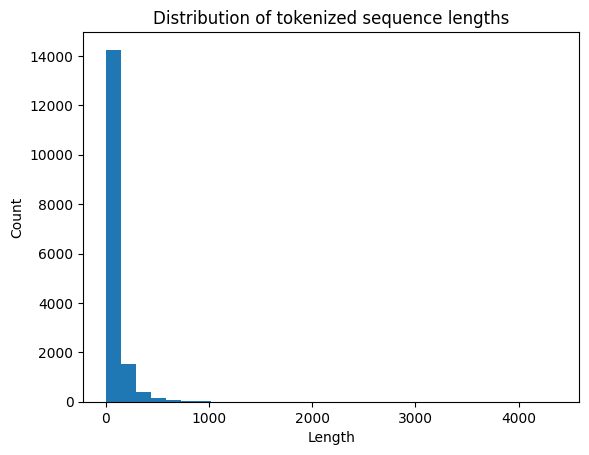

128

In [7]:
# How are sequence lengths distributed?
import matplotlib.pyplot as plt
lengths = [len(s) for s in token_seqs]
plt.figure()
plt.hist(lengths, bins=30)
plt.title("Distribution of tokenized sequence lengths")
plt.xlabel("Length")
plt.ylabel("Count")
plt.show()

# Choose a max length (cap at 128 or 95th percentile, whichever is smaller ceiling)
import numpy as np
p95 = int(np.percentile(lengths, 95))
MAX_LEN = min(128, max(16, p95))
MAX_LEN


In [8]:
# Pad / truncate to MAX_LEN
def pad_truncate(seq, max_len=128, pad_id=PAD_ID):
    if len(seq) >= max_len:
        return seq[:max_len]
    return seq + [pad_id] * (max_len - len(seq))

padded = [pad_truncate(s, MAX_LEN, PAD_ID) for s in token_seqs]
labels = df["stars"].astype(float).values
len(padded), len(labels), MAX_LEN


(16413, 16413, 128)

3. Form a torch dataset object based on the token sequences and labels, and split the data into a train and validation set.

In [9]:
from torch.utils.data import Dataset, DataLoader, random_split
import torch

# Define a custom PyTorch dataset class for IMDB reviews
class IMDBDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = torch.tensor(texts, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.float32)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return self.texts[idx], self.labels[idx]

# Example usage: Creating a dataset instance
dataset = IMDBDataset(padded, labels)

# Split dataset into training (80%) and validation (20%)
n_total = len(dataset)
n_train = int(0.8 * n_total)
n_val = n_total - n_train
train_set, val_set = random_split(dataset, [n_train, n_val], generator=torch.Generator().manual_seed(42))

# Create DataLoaders
BATCH_SIZE = 64
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)
len(train_loader), len(val_loader)


(206, 52)

In [10]:
print('Sample label:', labels[0]); print('Sample tokens:', padded[0][:20])

Sample label: 5.0
Sample tokens: [38, 10610, 532, 11, 9765, 1130, 2249, 11, 4788, 8301, 758, 622, 6, 2706, 81356, 1744, 36367, 16795, 513, 9517]


## Build the embedding based prediction model

Now that the data is duely tokenized, let's create a prediction model based on the embedding layer.

1. The first question you need to ask yourself is what kind of prediction problem are we dealing with? The target variable represents the number of stars associated with each comment.

Treating this as a regression problem seems relevant for two reasons :
- The target variable is qualitative ordinal, therefore values of stars can be compared
- This would help the model associate tokens with quantitative measures on only one dimension (as opposed to 5 dimensions in the case of classification) observations associated with each number of stars will actually benefit the training for all values of stars.

2. Build a prediction model based on your choice

In [11]:
# Get the vocabulary size from the tokenizer
vocab_size = max(max(seq) if len(seq)>0 else 0 for seq in token_seqs) + 1  # conservative; enc.n_vocab is also fine
try:
    vocab_size = max(vocab_size, enc.n_vocab)
except Exception:
    pass
vocab_size

import torch.nn as nn
import torch

# Define a neural network model for text regression
class TextRegressor(nn.Module):
    def __init__(self, vocab_size, embed_dim, pad_id=PAD_ID):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_id)
        self.fc = nn.Linear(embed_dim, 1)
    def forward(self, text):
        # text: (batch, seq_len)
        emb = self.embedding(text)                 # (B, L, D)
        mask = (text != PAD_ID).float().unsqueeze(-1)  # (B, L, 1)
        summed = (emb * mask).sum(dim=1)           # (B, D)
        denom = mask.sum(dim=1).clamp(min=1.0)     # avoid divide by zero
        pooled = summed / denom                    # (B, D) masked mean
        out = self.fc(pooled).squeeze(-1)          # (B,)
        return out


3. Print out the sructure of the model

In [12]:
EMBED_DIM = 64
model = TextRegressor(vocab_size=vocab_size, embed_dim=EMBED_DIM).to(device)
print(model)
sum(p.numel() for p in model.parameters()), device


TextRegressor(
  (embedding): Embedding(100277, 64, padding_idx=0)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


(6417793, 'mps')

4. Prepare and run the training loop for 50 epochs.

In [13]:
import torch.optim as optim
import torch.nn as nn
from tqdm import tqdm

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

def train(model, train_loader, val_loader, criterion, optimizer, epochs=50, device=device):
    history = {"train_loss": [], "val_loss": []}
    for epoch in range(1, epochs+1):
        model.train()
        running_loss = 0.0
        n_train = 0
        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}", leave=False):
            inputs = inputs.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            n_train += inputs.size(0)
        train_loss = running_loss / max(1, n_train)

        # Validation
        model.eval()
        val_running = 0.0
        n_val = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_running += loss.item() * inputs.size(0)
                n_val += inputs.size(0)
        val_loss = val_running / max(1, n_val)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoch {epoch:03d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")
    return history

history = train(model, train_loader, val_loader, criterion, optimizer, epochs=50)


Epoch 001 | train_loss=13.1373 | val_loss=5.5575


Epoch 005 | train_loss=1.1119 | val_loss=1.2637


Epoch 010 | train_loss=0.6481 | val_loss=1.0050


Epoch 015 | train_loss=0.4635 | val_loss=0.9650


Epoch 020 | train_loss=0.3642 | val_loss=1.0047


...

Epoch 030 | train_loss=0.2622 | val_loss=1.1838


Epoch 035 | train_loss=0.2328 | val_loss=1.3003


Epoch 040 | train_loss=0.2102 | val_loss=1.4341


Epoch 045 | train_loss=0.1920 | val_loss=1.5651


Epoch 050 | train_loss=0.1773 | val_loss=1.7039


## Error analysis

Error analysis consists in focusing on the observations in the training set and validation sets that were predicted the worst by the model. This often reveals potential inconsistencies in the data, and helps identifies improvement opportunies for our model.

1. Create a function that creates a Dataframe containing:
    - the prediction value
    - the true label of the observation
    - the tokenized input
    - the text input
Based on a data loader, the tokenizer, and the model.
Apply this function to both the train loader, and the val loader.

In [14]:
import pandas as pd
def evaluate_worst_predictions(model, dataloader, tokenizer, device=device, top_k=20):
    model.eval()
    preds, trues, toks = [], [], []
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs).cpu().numpy().tolist()
            preds.extend(outputs)
            trues.extend(labels.numpy().tolist())
            toks.extend(inputs.cpu().numpy().tolist())
    df_eval = pd.DataFrame({"pred": preds, "label": trues, "tokens": toks})
    df_eval["error"] = (df_eval["pred"] - df_eval["label"]).abs()
    # decode
    def safe_decode(seq):
        # strip padding zeros
        seq = [t for t in seq if t != PAD_ID]
        try:
            return tokenizer.decode(seq)
        except Exception:
            return str(seq)
    df_eval["text"] = df_eval["tokens"].apply(safe_decode)
    df_eval = df_eval.sort_values("error", ascending=False).reset_index(drop=True)
    return df_eval

val_eval = evaluate_worst_predictions(model, val_loader, enc, device=device, top_k=20)
train_eval = evaluate_worst_predictions(model, train_loader, enc, device=device, top_k=20)
len(val_eval), len(train_eval)


(3283, 13130)

2. Display the first ten rows of each dataframe to get an idea of the worst predicted data points. Is there anything that raises questions?

In [15]:
val_eval.head(10)

,pred,label,tokens,error,text
0,-8.781942,5.0,"[88265, 61058, 349, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",13.781942,quelle eclate
1,-6.269610,5.0,"[51557, 51557, 51557, 51557, 51557, 51557, 515...",11.269610,KKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKK...
2,-7.036386,4.0,"[1271, 682, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...",11.036386,To all
3,-6.995043,4.0,"[4012, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",10.995043,OK
4,-6.669166,3.0,"[32346, 79462, 912, 5199, 1716, 14278, 0, 0, 0...",9.669166,Too pricey no significant child reduction
5,14.334100,5.0,"[26840, 7839, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",9.334100,Very Good
6,13.888346,5.0,"[25013, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",8.888346,xxx
7,13.166384,5.0,"[49885, 7839, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",8.166384,Really Good
8,-2.976283,5.0,"[30599, 1762, 3900, 1948, 0, 0, 0, 0, 0, 0, 0,...",7.976283,Sempre il top
9,11.718571,4.0,"[32, 6387, 87099, 18434, 9157, 0, 0, 0, 0, 0, ...",7.718571,Aconselho vivamente


In [16]:
train_eval.head(10)

,pred,label,tokens,error,text
0,0.271892,5.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",4.728108,
1,0.271892,5.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",4.728108,
2,4.751819,1.0,"[34, 1826, 653, 842, 69596, 4809, 588, 4618, 2...",3.751819,C est un endroit merveilleux
3,4.649773,1.0,"[24378, 24378, 5809, 0, 0, 0, 0, 0, 0, 0, 0, 0...",3.649773,���������
4,4.486167,1.0,"[19841, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",3.486167,Super
5,4.418820,1.0,"[56948, 40574, 978, 481, 86323, 1522, 8047, 11...",3.418820,"Une agréable journée passée, la rencontre avec..."
6,1.854438,5.0,"[82681, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",3.145562,Bonjour
7,3.803800,1.0,"[13, 220, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",2.803800,.
8,3.669528,1.0,"[10156, 1027, 1070, 449, 856, 220, 20, 88, 236...",2.669528,"Just been there with my 5y old son for a day, ..."
9,3.643467,1.0,"[66, 96287, 4983, 2428, 0, 3625, 60404, 1880, ...",2.643467,c'était magique les enfants et nous même en on...


3. Calculate the mean error for each category of the target. Also calculate the number of samples belonging to each category. What do you think?

In [17]:
# Mean absolute error by star rating (rounded to nearest int)
import numpy as np
def round_stars(x): 
    try: 
        return int(round(x))
    except Exception:
        return int(x)
val_eval["stars_round"] = val_eval["label"].apply(round_stars)
train_eval["stars_round"] = train_eval["label"].apply(round_stars)

val_grp = val_eval.groupby("stars_round").agg(mean_abs_error=("error","mean"),
                                             n=("error","size")).reset_index().sort_values("stars_round")
train_grp = train_eval.groupby("stars_round").agg(mean_abs_error=("error","mean"),
                                                 n=("error","size")).reset_index().sort_values("stars_round")
val_grp, train_grp


(   stars_round  mean_abs_error     n
 0            1        1.842373   195
 1            2        1.075678   128
 2            3        0.918184   270
 3            4        0.878897   463
 4            5        0.721274  2227,
    stars_round  mean_abs_error     n
 0            1        0.582093   705
 1            2        0.417729   563
 2            3        0.327051  1066
 3            4        0.285233  1752
 4            5        0.194107  9044)

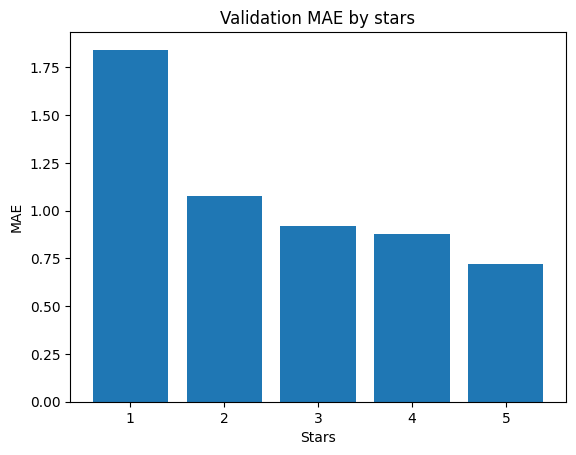

In [18]:
# Plot MAE by stars for validation
import matplotlib.pyplot as plt
plt.figure()
plt.bar(val_grp["stars_round"].astype(str), val_grp["mean_abs_error"])
plt.title("Validation MAE by stars")
plt.xlabel("Stars")
plt.ylabel("MAE")
plt.show()


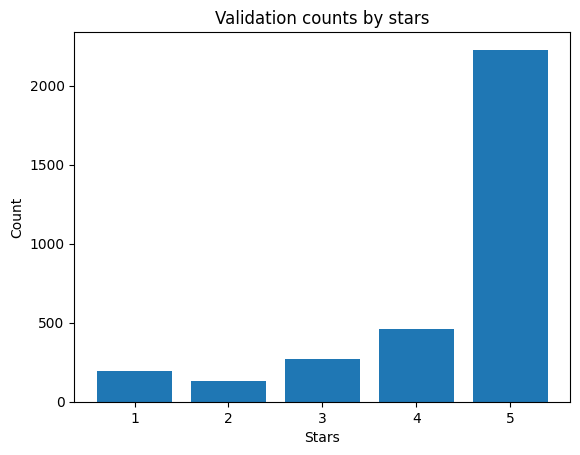

In [19]:
# Plot counts by stars for validation
plt.figure()
plt.bar(val_grp["stars_round"].astype(str), val_grp["n"])
plt.title("Validation counts by stars")
plt.xlabel("Stars")
plt.ylabel("Count")
plt.show()


In [ ]:
# # Save the trained model checkpoint (optional)
# torch.save(model.state_dict())


TypeError: save() missing 1 required positional argument: 'f'